In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df=pd.read_csv(r"C:\Users\Rawoo\OneDrive\Documents\Projects\walmart-sales-analysis-python\data\processed\walmart_cleaned.csv")
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Month_Name,Week,Quarter
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,February,5,1
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,February,6,1
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,February,7,1
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,February,8,1
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,March,9,1


In [15]:
weekly_trend = df.groupby("Date")["Weekly_Sales"].sum().reset_index()

# Create week index
weekly_trend["Week"] = range(1, len(weekly_trend) + 1)

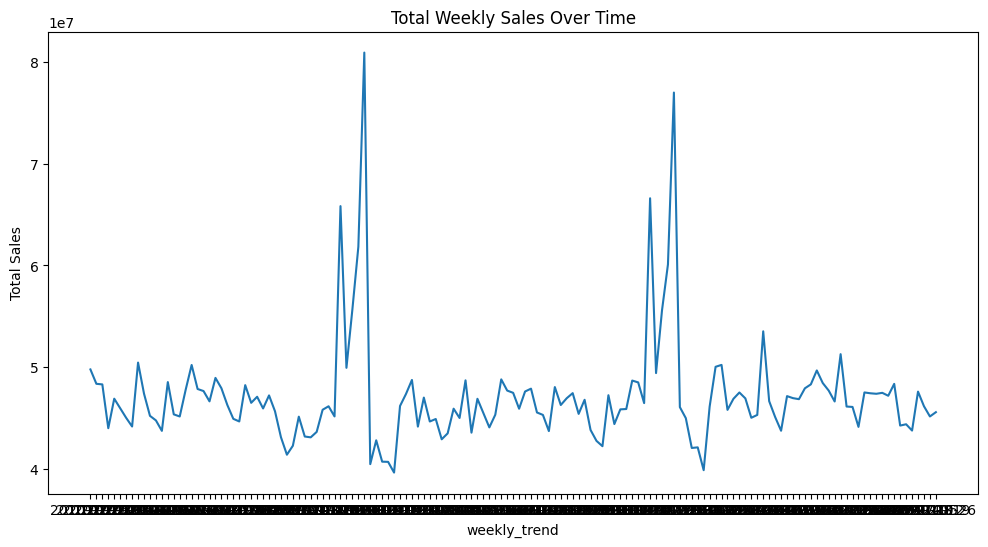

In [33]:
weekly_trend = df.groupby("Date")["Weekly_Sales"].sum().reset_index()

plt.figure(figsize=(12,6))
plt.plot(weekly_trend["Date"], weekly_trend["Weekly_Sales"])

plt.title("Total Weekly Sales Over Time")
plt.xlabel("weekly_trend")
plt.ylabel("Total Sales")
plt.savefig(r"C:\Users\Rawoo\OneDrive\Documents\Projects\walmart-sales-analysis-python\outputs\figures\weekly_sales_trend.png", dpi=300, bbox_inches="tight")

plt.show()


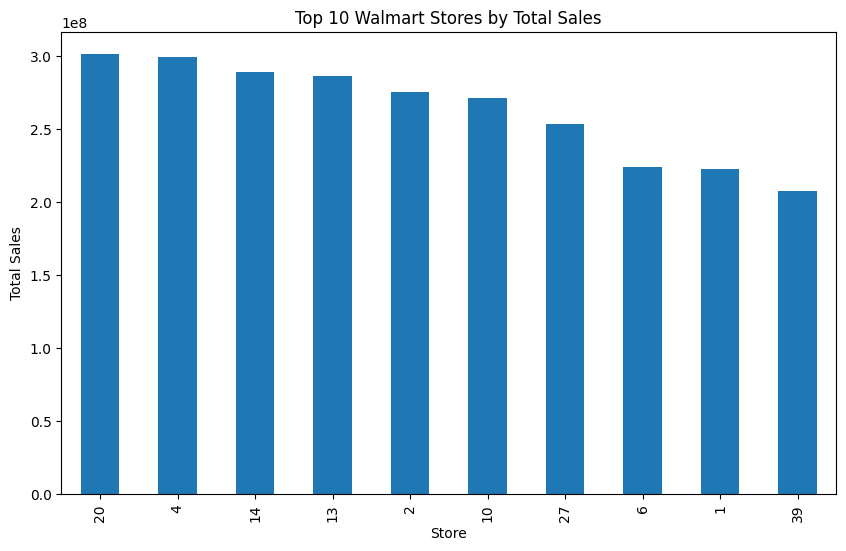

In [30]:
store_sales = df.groupby("Store")["Weekly_Sales"].sum().sort_values(ascending=False)

top10 = store_sales.head(10)

plt.figure(figsize=(10,6))
top10.plot(kind="bar")

plt.title("Top 10 Walmart Stores by Total Sales")
plt.xlabel("Store")
plt.ylabel("Total Sales")
plt.savefig(r"C:\Users\Rawoo\OneDrive\Documents\Projects\walmart-sales-analysis-python\outputs\figures\top10_stores_sales.png", dpi=300, bbox_inches="tight")
plt.show()

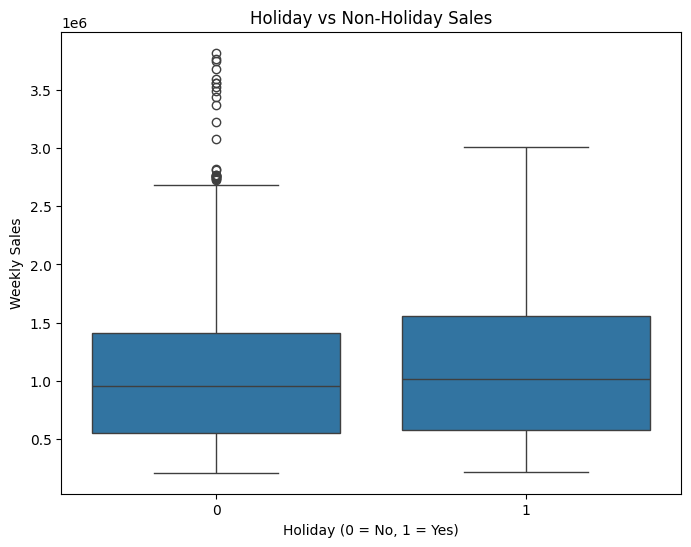

In [31]:
plt.figure(figsize=(8,6))

sns.boxplot(x="Holiday_Flag", y="Weekly_Sales", data=df)

plt.title("Holiday vs Non-Holiday Sales")
plt.xlabel("Holiday (0 = No, 1 = Yes)")
plt.ylabel("Weekly Sales")
plt.savefig(r"C:\Users\Rawoo\OneDrive\Documents\Projects\walmart-sales-analysis-python\outputs\figures\HolidayVsNonHolidaySales.png", dpi=300, bbox_inches="tight")
plt.show()

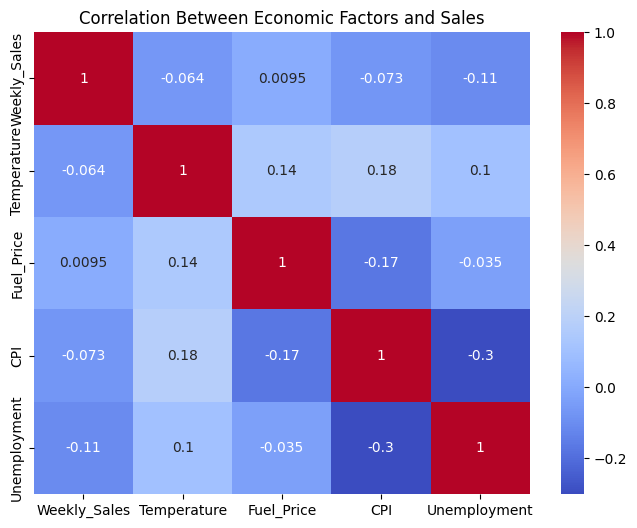

In [29]:
corr = df[["Weekly_Sales","Temperature","Fuel_Price","CPI","Unemployment"]].corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Between Economic Factors and Sales")
plt.savefig(r"C:\Users\Rawoo\OneDrive\Documents\Projects\walmart-sales-analysis-python\outputs\figures\correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

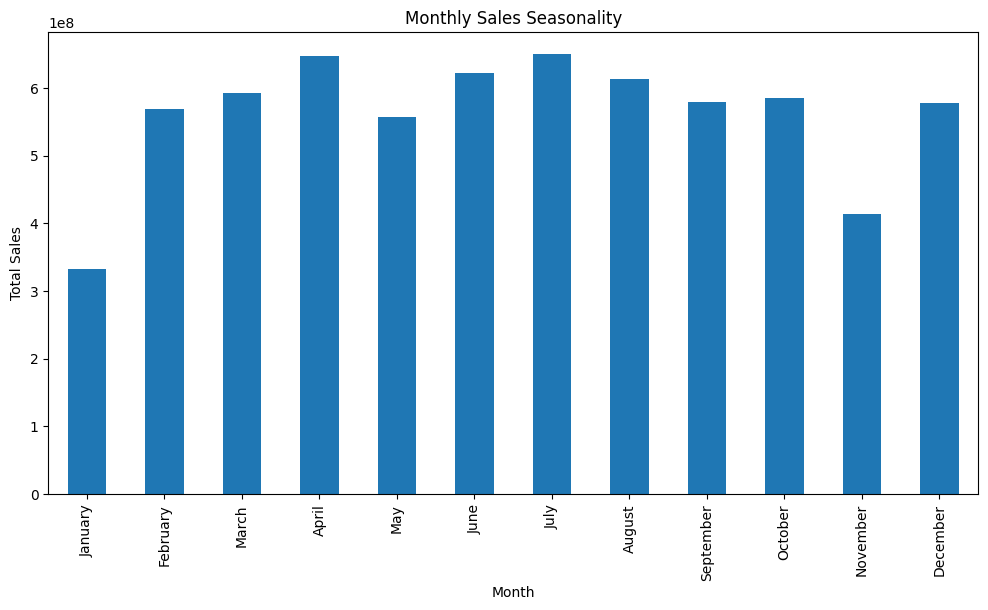

In [32]:
monthly_sales = df.groupby("Month_Name")["Weekly_Sales"].sum()

order = [
"January","February","March","April","May","June",
"July","August","September","October","November","December"
]

monthly_sales = monthly_sales.reindex(order)

plt.figure(figsize=(12,6))

monthly_sales.plot(kind="bar")

plt.title("Monthly Sales Seasonality")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.savefig(r"C:\Users\Rawoo\OneDrive\Documents\Projects\walmart-sales-analysis-python\outputs\figures\MonthlySalesSeasonality.png", dpi=300, bbox_inches="tight")
plt.show()